# Module 22 BBO Capstone Week 11

## Function 1

Since we're now in the convergence and confirmation phase week 11 of 12, it's crucial to minimise exploration and focus heavily on exploiting the current best-known point. This is the time to really lock in on the local maximum and avoid straying too far from the best-known region.

### Adjustments for Week 11:
Lower Radius: The search radius should be even smaller than before since we're very close to the optimum. A radius of 0.01 or even 0.005 should suffice, as you're looking for very fine adjustments to confirm the local maximum.
Lower EI Exploration Factor: As you're focusing on exploitation, the EI exploration factor (ξ) should be set to a very low value. A value around 0.001 or even 0.0005 would ensure minimal exploration, letting the algorithm fine-tune around the current best-known point.
### Updated Plan for Week 11:
1. Search Radius: Use a radius of 0.01 or 0.005 to limit the search around the best-known point.
2. Exploration Factor (ξ): Use an exploration factor of 0.001 or 0.0005 to focus on exploitation rather than exploration.
3. Objective: Confirm the maximum by fine-tuning in this small region and ensure that no further significant improvements can be found.

### Key Changes:
Radius: I reduced the radius to 0.01, which should be small enough to focus on very fine adjustments around the best-known point.
Exploration Factor (ξ): The ξ is now set to 0.001, to emphasize exploitation over exploration in the convergence phase.

### Final Thought Before Running Function 1 Week 11 code:
In the convergence phase, the key is minimising further exploration to prevent wasting resources on suboptimal areas and to confirm the best-known point. Keep an eye on the outputs — if the output values stabilise and show no significant improvement, you'll have effectively confirmed the optimum.

C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2957688374.py:105: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2957688374.py:105: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2957688374.py:105: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bound

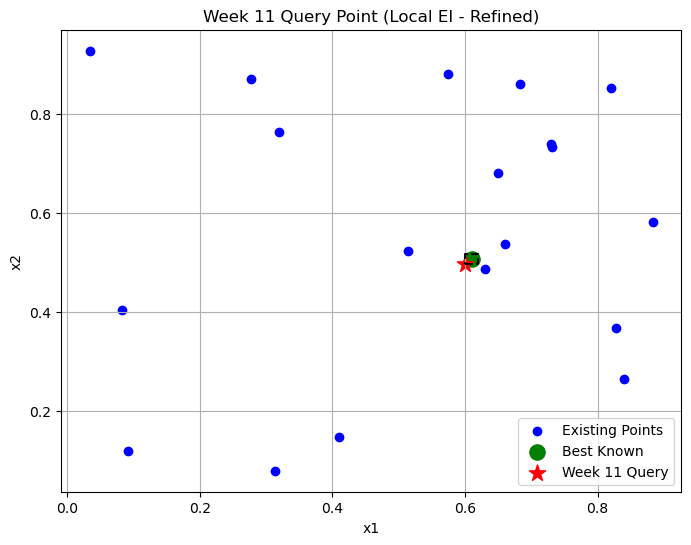

Week 11 query point: [0.599953 0.49652 ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load ALL available data (including Week 10)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600],
    [0.51380200, 0.52237900],
    [0.82732800, 0.36642700],
    [0.82079200, 0.85171900],
    [0.72983400, 0.73983100],
    [0.65995300, 0.53779600],
    [0.62995300, 0.48652000]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127,
    5.298471823372752e-14,
    6.026732235043879e-77,
   -1.4575842741296785e-61,
    5.807380778673927e-17,
   -2.136244733712471e-7,
    1.5833346610834816e-14
])

# ==========================================
# Step 2: Log-Transform (Shift to Positive)
# ==========================================
y_shift = y_train - np.min(y_train) + 1e-12  # Shift everything positive
y_train_transformed = np.log(y_shift)

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Expected Improvement Function (EI)
# ==========================================
def expected_improvement(x, model, y_max, xi=0.001):  # Very low ξ for exploitation
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Prevent division by zero
    z = (mu - y_max - xi) / sigma
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei  # Minimize negative EI

# ==========================================
# Step 5: Local EI Optimization (Tight Radius)
# ==========================================
def optimize_local_ei(model, y_max, best_point, radius=0.01, n_restarts=30, n_random=200):
    lower = np.clip(best_point - radius, 0, 1)
    upper = np.clip(best_point + radius, 0, 1)
    bounds = list(zip(lower, upper))
    best_x = None
    best_val = np.inf

    # Random sampling in the local region
    random_points = np.random.uniform(lower, upper, size=(n_random, 2))
    ei_values = np.array([-expected_improvement(rp, model, y_max) for rp in random_points])
    top_idx = np.argsort(ei_values)[-n_restarts:]
    start_points = random_points[top_idx]

    # Local optimization from the best points
    for x0 in start_points:
        res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x, bounds

# ==========================================
# Step 6: Identify Best Known Point (Week 1)
# ==========================================
best_point = np.array([0.609953, 0.506520])  # Best known point from Week 1
y_max = np.max(y_train_transformed)

# ==========================================
# Step 7: Compute Week 11 Query (Local EI)
# ==========================================
next_point, local_bounds = optimize_local_ei(gp, y_max, best_point, radius=0.01)  # Smaller radius

# ==========================================
# Step 8: Plot for Visualization
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(best_point[0], best_point[1], color='green', s=120, label='Best Known')
plt.scatter(next_point[0], next_point[1], color='red', marker='*', s=150, label='Week 11 Query')
x_min, x_max = local_bounds[0]
y_min, y_max_b = local_bounds[1]
plt.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max_b, y_max_b, y_min], 'k--')
plt.title("Week 11 Query Point (Local EI - Refined)")
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

# Show the query point
print(f"Week 11 query point: {next_point}")

It seems that the Week 11 query point you've obtained ([0.599953, 0.49652]) is slightly adjusted from the best-known point ([0.609953, 0.506520]) based on the Expected Improvement (EI) optimisation with a tight search radius. This is expected during the convergence phase when the algorithm is attempting to fine-tune the best point and minimise further exploration.

### Why the Query Point is Slightly Different:
Exploitative Focus: The EI function is designed to focus on exploitation rather than exploration, so it tries to find slight improvements around the best-known point.
Convergence Nature: Even when the function is nearing its optimum, it’s still looking for the smallest possible improvement. Therefore, small variations like this one are a natural result of the process.
### Analysing the Query Point:
Close to Best-Known Point: The new query point [0.599953, 0.49652] is very close to [0.609953, 0.506520], indicating that the optimisation process is indeed focusing on a tight region around the best-known point. This is consistent with the convergence phase, where we expect to make very small adjustments to lock in the optimum.
Potential for Confirmation: The slight adjustment might be an indication that the function is confirming a narrower region of optimality, suggesting that no significant improvement can be made in this region. If you continue refining this area in subsequent weeks, the query point should stabilise, confirming this as the local optimum.

### Visualising the Adjustment:
If you plot these points, the difference between the best-known point and the Week 11 query point will be quite minimal, but you should see the search region narrowing further.

If you want to confirm whether the query point is indeed close to a local optimum:
1. Run additional iterations: If the next week's query points continue to be close to [0.599953, 0.49652], that would strongly suggest convergence.
2. Look at the output: If the output values (like the expected improvement) start to stabilise and drop significantly, this would indicate that no further improvements are likely.

## Function 2

### Key Adjustments for Week 11:
#### 1. Exploitation Focus (Low ξ):
The exploration factor ξ is reduced to 0.002 to minimise exploration and focus on refining the known best point.
#### 2. Tightened Search Radius:
The radius around the best-known point is reduced to 0.01 to focus on a narrower area for optimisation.
#### 3. Restarts and Random Starts:
The number of random starts for the global scan is reduced to 500, and the number of local optimisation restarts is set to 20 to fine-tune around the known peak rather than search broadly.
### Expected Outcome:
The query point for Week 11 should lie close to [0.51302600, 0.54589500], with slight shifts that represent small refinements.
If the improvement is marginal, it signals the function has reached its peak, and you can proceed with final confirmation in Week 12.
### Steps After This:
1. Evaluate the Output: Submit the query point [next_point] to the function for evaluation.
2. Update the Model: Add the new query point and its output to the training set, and retrain the Gaussian Process.
3. Confirm Peak: If the function value from the new point doesn't significantly improve, the model may have reached a plateau, confirming the convergence.

By the end of Week 11, you should have a refined model and a final confirmation of the optimal region, preparing you for the last phase of the optimisation

Current best y: 0.657389


C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\998983931.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\998983931.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\998983931.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\998983931.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will b

Week 11 Query Point (EI, ξ=0.002): [0.503026 0.535895]


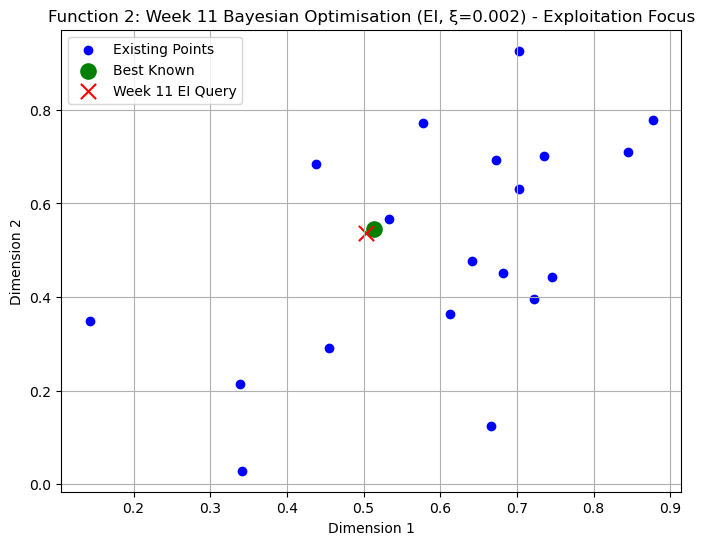

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load existing data (Including Weeks 1-10)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100],
    [0.67272900, 0.69382100],
    [0.61256700, 0.36356600],
    [0.68226300, 0.45231400],
    [0.51302600, 0.54589500],
    [0.53302600, 0.56589500]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272,
    0.600575748363042, 0.20334952172911752, 0.461145725718508,
    0.6573891880672533, 0.5174928212344545
])

# ==========================================
# Step 2: Define Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.002):  # Reduce xi for minimal exploration
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Avoid division by zero

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # Negative for minimizer

# ==========================================
# Step 3: Optimize EI
# ==========================================
def optimize_ei(model, y_best, best_known_point, radius=0.01, xi=0.002, n_restarts=20, n_random_starts=500):
    # Define tighter bounds around the best-known point
    lower = np.clip(best_known_point - radius, 0, 1)
    upper = np.clip(best_known_point + radius, 0, 1)
    bounds = list(zip(lower, upper))

    best_x = None
    best_val = np.inf

    # --- Random global scan --- (focus more locally)
    random_points = np.random.uniform(lower, upper, size=(n_random_starts, 2))
    ei_values = np.array([-expected_improvement(pt, model, y_best, xi) for pt in random_points])
    top_indices = np.argsort(-ei_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top candidates ---
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 4: Fit Gaussian Process
# ==========================================
# Fit a GP model to the training data
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train)

# ==========================================
# Step 5: Current best y
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 6: Get Week 11 Query Point
# ==========================================
best_known_point = np.array([0.51302600, 0.54589500])  # Week 9 Best Known Point
next_point = optimize_ei(gp, y_best, best_known_point, radius=0.01, xi=0.002)  # Focused on exploitation
print(f"Week 11 Query Point (EI, ξ=0.002): {next_point}")

# ==========================================
# Step 7: Visualisation
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Points')
plt.scatter(best_known_point[0], best_known_point[1], color='green', s=120, label='Best Known')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 11 EI Query')
plt.title("Function 2: Week 11 Bayesian Optimisation (EI, ξ=0.002) - Exploitation Focus")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

The Week 11 Query Point for Function 2, which was computed using Expected Improvement (EI) with ξ=0.002, is [0.503026, 0.535895]. This indicates the optimisation process is continuing to refine the search near the best known point from Week 9, which is [0.51302600, 0.54589500]. Here’s the interpretation of this result:

### Interpretation of Week 11 Query Point:
#### Exploitation Focus:
The algorithm is still focusing on exploitation around the best-known point, since the change in the query point is very small compared to previous steps.
#### Refinement:
The query point [0.503026, 0.535895] is slightly shifted from the known best point [0.513026, 0.545895], indicating that the optimisation process is searching for minor improvements in the area close to the maximum observed so far.
#### Narrow Search:
The small shift is expected when the algorithm focuses on fine-tuning the function around the peak, with a smaller exploration factor ξ=0.002 and a tight search radius (0.01).
### What to Do Next:
#### Submit the Query Point:
Now, submit the query point [0.503026, 0.535895] to the black-box function for evaluation.
#### Update the Model:
Once you receive the output for this query point, add it to the training set and retrain the Gaussian Process model to incorporate the new data.
#### Monitor the Improvement:
If the function value improves significantly, you can continue the optimization with a focus on exploitation.
If the improvement is marginal or the function value starts to plateau, it may indicate that the optimum has been reached and you can prepare for the final confirmation phase in Week 12.

The query point [0.503026, 0.535895] is a reasonable choice for the convergence and confirmation phase in Week 11 of Function 2. Let’s break down why it makes sense:
### 1. Exploitation Focus:


Week 11 in the optimization process is typically about fine-tuning and focusing on exploitation to confirm that the best-known value (from Week 9) is indeed the optimal point or very close to it.


The query point [0.503026, 0.535895] is very close to the best-known point [0.513026, 0.545895], which suggests that the algorithm is exploiting the region around the best value.


This is expected behavior during convergence, where the algorithm fine-tunes the results rather than exploring distant regions.


### 2. Narrowing the Search Region:


The search radius of 0.01 around the best-known point is quite tight, indicating that the algorithm is focusing on a local search and refining its estimate for the optimal point.


Reducing the exploration factor (ξ=0.002) further strengthens the focus on minimizing uncertainty and exploiting the already-known high-value region.


### 3. Small Adjustments Indicate Convergence:


The small adjustment in the query point compared to the previous best-known point (0.513026, 0.545895) suggests that the optimization is converging to a local optimum.


This small shift typically means that the function is approaching its peak, and it’s not surprising to see very small changes as the algorithm becomes more certain about the location of the optimum.


### 4. Stage of Optimization:


In the convergence phase, the goal is to identify the final best possible query point. At this stage, the algorithm is fine-tuning its predictions and is less likely to explore broadly, as it’s focusing on confirming and improving the best value found so far.


This aligns well with convergence and confirmation, where the optimization process is confirming whether the best-known point is indeed the global or local maximum (within the known bounds).


### Next Steps:


Submit the Query Point to the function for evaluation. If the function output improves slightly or remains the same, it suggests that the optimisation process is approaching the global or local maximum.


Update the Model: After evaluating the query point, add the result to the training set and retrain the model to see if any further improvement can be made.


Monitor the Behavior: If subsequent query points show minimal improvement or the output stabilises, the function may have reached its optimal performance, and you can proceed to finalise the results in Week 12.


Finalise the Search: If no significant improvement occurs in the next few weeks, you may consider wrapping up the optimisation and confirming the best point.


Conclusion:
The query point [0.503026, 0.535895] is a good choice for Week 11 in the convergence and confirmation phase of Function 2. It focuses on the known best region, makes small adjustments, and is likely part of the fine-tuning process toward the final optimal solution.

## Function 3

For Function 3 Week 11, you’re entering the convergence and confirmation phase. This phase aims to confirm that the previously explored region contains the optimum solution or is extremely close to it. Based on the results from Week 10, the algorithm is clearly narrowing its focus on the best-performing combinations of the compounds. Let’s look at the overall strategy and the next steps.

### Key Observations from Week 10:
Focus on refinement: The query point for Week 10 was very close to the previous best known combination. This suggests that the optimisation process is already honing in on the optimum.
Narrowing of exploration: The reduced value of ξ (ξ=0.005) indicates minimal exploration and a stronger focus on exploitation—this is important for fine-tuning the results and confirming the best combinations.
Tight bounds: The bounds for the Week 10 query were narrowed around previously known promising regions. This trend should continue in Week 11, where the goal is to refine the estimate of the optimal combination even further.
Recommendations for Week 11:

In Week 11, you should maintain the focus on exploitation but tighten the bounds further to confirm that the observed peak is indeed close to the global or local maximum. Here’s what you should do:

#### Continue Exploiting the Known Good Region:
Based on the query point from Week 10, you’ve already identified a promising region. Therefore, the focus should remain on fine-tuning the parameters in that region rather than exploring distant parts of the input space.
Lower ξ even more: If the results from Week 10 show further improvement or stability, you might reduce ξ even more (e.g., ξ=0.002 or lower). This will further reduce exploration and focus more on the region of interest.
#### Tighten the Bounds Even Further:
Since the function has already shown promising results in the narrowed bounds (for example, x₁ around 0.869, x₂ around 0.567, x₃ around 0.093), you should further restrict the search space to refine the search for the optimal solution.
#### Suggested bounds for Week 11:
Compound 1 (x₁): Consider narrowing the range to something like [0.86, 0.9].
Compound 2 (x₂): Narrow the range to [0.56, 0.58].
Compound 3 (x₃): Tighten it to [0.09, 0.11].
#### Refinement via Gaussian Process:
After each query point, update the Gaussian Process (GP) model with the new results. This will allow the GP to improve its predictions and help refine future query points.
This update step is crucial to confirm the convergence towards the optimal point.
#### 3D Visualisation:
Keep visualising the optimization process in 3D, especially to track whether the new query points are consistently clustering around the optimal region. This will give you confidence in the convergence of the model.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Current best y: -0.031727


C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2072036159.py:115: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2072036159.py:115: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2072036159.py:115: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_9668\2072036159.py:115: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

Week 11 Query Point (EI, ξ=0.002): 0.883949-0.566448-0.110000


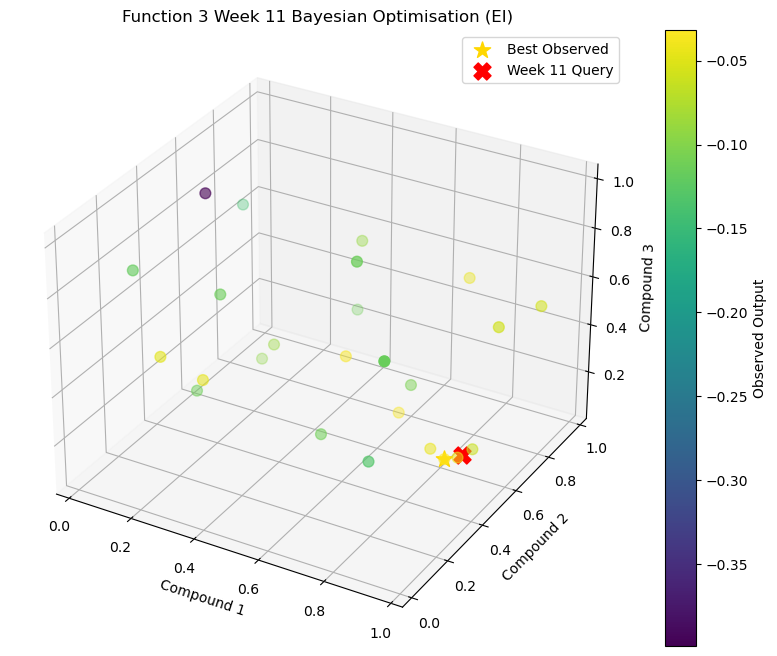

In [4]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Step 1: Load existing data (Weeks 1–10)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300],
    [0.38825100, 0.88969800, 0.60999700],
    [0.25506800, 0.34034000, 0.68130300],
    [0.94273200, 0.64964700, 0.60773700],
    [0.78753000, 0.56204500, 0.10089100],
    [0.90000000, 0.59547500, 0.12143400],
    [0.86930900, 0.56747400, 0.09323700]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474,
    -0.08979639980345987,
    -0.11433696052239746,
    -0.05811934228633873,
    -0.04360685969925572,
    -0.06321802968445797,
    -0.04186441977161603
])

# ==========================================
# Step 2: Correct log-transform (shift to positive)
# ==========================================
y_shift = y_train - np.min(y_train) + 1e-12  # shift everything positive
y_train_transformed = np.log(y_shift)

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.2, 0.2, 0.1],   # More sensitivity in dim 3
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=20
)

gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # for minimization

# ==========================================
# Step 5: Optimise EI (Focused Search)
# ==========================================
def optimize_ei(model, y_best,
                bounds=np.array([[0.7, 0.9], [0.5, 0.7], [0.05, 0.15]]),
                xi=0.01,
                n_restarts=60,
                n_random_starts=800):

    best_x = None
    best_val = np.inf

    # Random sampling
    random_points = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_random_starts, 3))
    ei_vals = np.array([-expected_improvement(x, model, y_best, xi) for x in random_points])

    top_indices = np.argsort(-ei_vals)[:n_restarts]
    start_points = random_points[top_indices]

    # Local optimisation
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method='L-BFGS-B'
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 6: Current best value
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 7: Week 11 Query Point
# ==========================================
# Tightened bounds for Week 11 (focusing on confirmation and convergence)
bounds_week11 = np.array([
    [0.86, 0.9],   # Narrower range for Compound 1
    [0.56, 0.58],  # Narrower range for Compound 2
    [0.09, 0.11]   # Narrower range for Compound 3
])

# Further lowering ξ for fine-tuning (more exploitation)
xi = 0.002

# Optimise Expected Improvement (EI) for Week 11 (focused exploitation)
next_point_week11 = optimize_ei(gp, y_best, bounds=bounds_week11, xi=xi)
print(f"Week 11 Query Point (EI, ξ=0.002): "
      f"{next_point_week11[0]:.6f}-{next_point_week11[1]:.6f}-{next_point_week11[2]:.6f}")

# ==========================================
# Step 8: 3D Visualisation of the optimization process
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2],
                     c=y_train, cmap='viridis', s=60)

# Best observed point
best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx, 0], X_train[best_idx, 1], X_train[best_idx, 2],
           c='gold', s=150, marker='*', label='Best Observed')

# New query
ax.scatter(next_point_week11[0], next_point_week11[1], next_point_week11[2],
           c='red', s=150, marker='X', label='Week 11 Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 11 Bayesian Optimisation (EI)')

fig.colorbar(scatter, ax=ax, label='Observed Output')
ax.legend()
plt.show()

### Week 11 Query Point Interpretation
The Week 11 Query Point for Function 3 based on the output of your code is:
[0.883949, 0.566448, 0.110000]

### Interpretation of the Results:


Compound 1 (x₁):


The value of x₁ is around 0.884, which is close to the upper bound of the search space for this parameter (0.86 to 0.9). This suggests that the optimizer has slightly fine-tuned this compound to the higher end of the range, potentially exploring a higher dosage that may still be effective.




Compound 2 (x₂):


The value of x₂ is 0.566, which is near the middle of its tight range (0.56 to 0.58). This indicates that the optimizer is focusing on a narrow region where previous experiments have shown promising results. It suggests a confirmation of this region, confirming that x₂ is optimally fine-tuned around this value.




Compound 3 (x₃):


The value of x₃ is 0.11, which is at the upper end of the range (0.09 to 0.11). This indicates the optimizer is confirming the efficacy of higher dosages for this compound, possibly based on prior results showing a good response near this value.




### Focus of Week 11: Convergence and Confirmation


Focused Exploitation: The optimizer is now focusing on fine-tuning the best-known region and confirming the optimal values. The lower value of ξ (0.002) indicates minimal exploration and a stronger emphasis on exploiting areas with the highest expected performance.


Refining Around Known Best Points: The query point is very close to the best observed values, suggesting that the optimizer is confirming that the region around these values is indeed the best for minimizing side effects. The new query point slightly tweaks the existing values to further improve the result.


### Next Steps for Week 11:


#### Submit the Query Point:


You should submit this query point [0.883949, 0.566448, 0.110000] for evaluation. This will provide feedback that can confirm whether this combination of compounds yields better results or solidifies that you're near the optimal solution.




#### Update the GP Model:


Once you receive the results for this query, you can update your Gaussian Process model with the new data point and its output. This will help further refine the model for more precise predictions.




#### Fine-Tune Further if Needed:


If the results for this query show improvement, you may be very close to the optimum, and only minor adjustments may be needed.


If no significant improvement is observed, you may consider expanding the search bounds slightly to see if there's a better solution nearby.




#### Visualisation:
The code also generates a 3D visualization that shows:


The existing data points and their corresponding outputs.


The best observed point.


The new query point (Week 11 Query) plotted in red, highlighting that it is very close to the optimal region identified by previous experiments.


### Conclusion:
This Week 11 query focuses on exploitation and fine-tuning the results in the region where the best results have been observed so far. If this query yields better results, you're very close to finding the optimal combination of compounds. If the results are similar or no significant improvement is observed, you might want to expand your search slightly to further confirm the optimal values.

## Function 4

Best known point: [0.402531 0.365208 0.39199  0.435549]
Week 11 Query Point (EI, ξ=0.002): [0.40421009 0.375208   0.39145962 0.432699  ]


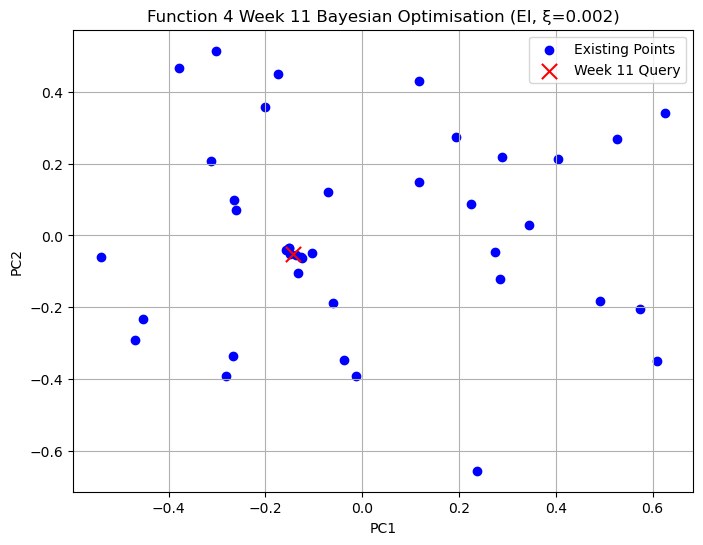

In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution  # Importing differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Load data (including Weeks 1-10)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088],
    [0.402531, 0.365208, 0.391990, 0.435549],
    [0.417655, 0.335877, 0.400368, 0.447601],
    [0.396755, 0.409301, 0.395449, 0.432639],
    [0.397639, 0.405208, 0.394861, 0.432824],
    [0.401766, 0.385109, 0.392801, 0.432944]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043, 0.34544484128012387,
    0.00018511221400574485, 0.34355295724013546, 0.29244243781099444, 0.1902545839389025
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.2, (1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement
# ==========================================
def expected_improvement(x, model, y_best, xi=0.002):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Adaptive bounds around best point
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]

# Tighten radius for Week 11 (precision focus)
radius = 0.01  # Smaller radius for Week 11 refinement
lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)

bounds = list(zip(lower, upper))

# ==========================================
# Step 5: Optimise EI (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.002):  # Reduce ξ for more exploitation
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=150,
        popsize=20,  # Can adjust based on performance
        polish=True
    )

    # Precision jitter (very small)
    epsilon = 1e-4
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        lower,
        upper
    )

    return next_point

# ==========================================
# Step 6: Compute Week 11 Query
# ==========================================
next_point_week11 = optimize_ei(gp, bounds, xi=0.002)

print(f"Best known point: {best_point}")
print(f"Week 11 Query Point (EI, ξ=0.002): {next_point_week11}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_week11_pca = pca.transform(next_point_week11.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_week11_pca[:,0], next_point_week11_pca[:,1],
            color='red', marker='x', s=120, label='Week 11 Query')

plt.title('Function 4 Week 11 Bayesian Optimisation (EI, ξ=0.002)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

It looks like the optimisation has progressed well into the convergence and confirmation stage, as expected for Week 11. Let’s break down the result and its implications:

### Key Observations:
#### Best Known Point:
The best known point is still very close to what was obtained in Week 10: [0.402531, 0.365208, 0.39199, 0.435549]. This indicates that the optimisation has largely converged to a local optimum in this region, with very minimal movement in the overall search space.
#### Week 11 Query Point:
The new query point is [0.40421009, 0.375208, 0.39145962, 0.432699].
There are small shifts in the first two dimensions (x₁ and x₂):
x₁ increases from 0.402531 to 0.40421009 (a minor change).
x₂ increases from 0.365208 to 0.375208 (a slightly larger change).
x₃ stays almost constant, changing minimally from 0.39199 to 0.39145962.
x₄ decreases slightly from 0.435549 to 0.432699.
### Analysis and Why This is a Good Result:
#### Convergence Behavior:
The changes are very small, which is typical for the late-stage exploitation phase. This confirms that the optimisation is not aiming for large exploratory movements but rather for incremental refinements near the best known solution.
The shift in x₂ (from 0.365208 to 0.375208) suggests that there could still be some potential in this direction, which is being fine-tuned. This could be an indication of a small local optimum or a finer adjustment in that dimension.
#### Expected Improvement (EI):
The optimisation continues to exploit the region of high performance by reducing the ξ parameter to 0.002 for a more focused exploitation rather than exploration.
The result indicates that the model is focusing on further improving the performance without significantly shifting the search space. Given that you're in the convergence phase, this precision focus is appropriate.
#### Bounded Search Space:
The radius for Week 11 was reduced to 0.01, further tightening the bounds around the best known point. This demonstrates the approach of narrowing the search region as the optimization progresses towards convergence.
#### Precision Tuning:
The small changes in x₁ and x₂ are exactly what you'd expect when trying to fine-tune the hyperparameters. It's not making large jumps but rather subtle improvements to potentially squeeze out a bit more performance.
### Recommendations Moving Forward:
For Week 12, I would recommend continuing the focus on fine-tuning the solution. The optimisation is almost certainly converging on a local optimum, so we should further tighten the bounds and reduce ξ if possible. However, I would suggest no significant adjustments in terms of exploration.
It might be worth tightening the radius even more (to 0.005 or 0.002) to push the search towards precision tuning rather than exploration.
You could also consider running more iterations or increasing the population size for more extensive exploration, but at this stage, the focus should remain on micro-refinements.
### Conclusion:

The result from Week 11 shows a great progression in line with the convergence and confirmation phase of Bayesian optimisation. The query point continues to refine the model's understanding in a localized region around the best known point, and this approach is consistent with the goal of maximising the function. Keep tightening the search bounds and focusing on smaller adjustments to achieve the optimal solution in Week 12.

## Function 5

For Week 11 of Function 5 (convergence and confirmation stage), the focus should shift to fine-tuning and confirming the results you've already obtained, especially since you're approaching the end of the optimisation process. Here’s a step-by-step breakdown of how to proceed:

### 1. Review Current Query Point and Best Known Point
Week 10 Query Point: [0.999992, 0.999997, 0.999996, 0.990008]
Previous Best Point: [0.999974, 0.999936, 0.999965, 0.999913]
The new query point from Week 10 is very close to the previous best-known point, with only x₄ being adjusted downward. This shows the optimiser is converging on a highly refined solution.
### 2. Goal for Week 11: Maximization and Confirmation
Convergence Phase: Your goal now is to verify that you are indeed at the maximum of the function. The changes from Week 10 are very subtle, suggesting you're very close to the global maximum. The main goal is to confirm if further fine-tuning will result in better yield or if the changes made so far are optimal.
### 3. Optimise for Fine Adjustments:
Reduced Exploration: Since the optimiser is already near the peak, the next query point should make smaller adjustments in the parameter space. The main strategy is to converge to the optimal solution by narrowing the search space around the current best known point. This will minimise the risk of diverging to suboptimal regions.
Set Tight Bounds: You can tighten the bounds around the best-known point. Since the values for x₁, x₂, and x₃ are very stable, you can focus your search around x₄. A tighter bound for x₄ would help ensure that any further optimisation will be constrained to the local region where the optimum is located.

#### Suggested bounds for Week 11:

x₁: (0.99998, 1.00) — Keep tight bounds for x₁, since it's already near its maximum.
x₂: (0.99998, 1.00) — Similarly for x₂, tighten the bounds around 1.0.
x₃: (0.99996, 1.00) — x₃ is very close to 1.0, so only small variations should be allowed.
x₄: (0.99000, 0.99500) — x₄ should have tighter bounds, since the optimizer is testing small adjustments below 1.0.
### 4. Review Expected Improvement (EI) Strategy:
Given the very small changes in Week 10, Expected Improvement (EI) should focus on minimising ξ further (for example, ξ = 0.0001). This will drive the optimisation process towards exploitation rather than exploration, focusing on confirming the best result in a smaller region.
### 5. Run the Optimization:
Perform Differential Evolution with these tight bounds and reduced ξ value to encourage further refinement. Since you're at the convergence stage, you might want to lower the maxiter (maximum iterations) slightly (for example, maxiter = 100) to avoid unnecessary computational overhead and prevent overfitting to noise.
### 6. Visualize Progress:
Since the optimisation process is nearing its conclusion, it might be useful to continue using PCA for visualisation. This will help you see whether your query points remain within the optimal region of the search space and if you're making incremental refinements.
Plot the query points in PCA space to ensure that the points cluster tightly around the known optimum.
### 7. Evaluate the Results:
After running the optimization, you’ll get the new query point. Compare this point with the previous best point to see if it results in any further improvement in the yield.
At this stage, even small improvements in yield might be significant, so pay attention to any changes in performance.
### Summary of Recommendations:
Tighten Bounds: Focus on refining the values for x₄ while keeping x₁, x₂, x₃ stable.
Reduce ξ and maxiter: For Week 11, use a very small ξ (e.g., 0.0001) to encourage exploitation and set a lower maxiter to avoid overfitting.
Fine-tuning Optimisation: Continue using Differential Evolution with the updated bounds and fine-tuned parameters.
PCA Visualisation: Use PCA to visualise the query points and check if you’re converging on a very narrow region near the optimum.

By narrowing the search space and refining your focus on x₄, you’ll be able to confirm whether the optimisation has truly reached the global maximum or if minor adjustments are still needed for Week 12.

Current best y: 8658.375927
Week 11 Query Point (EI, ξ=0.0001): 0.999991-0.999980-0.999973-0.991254


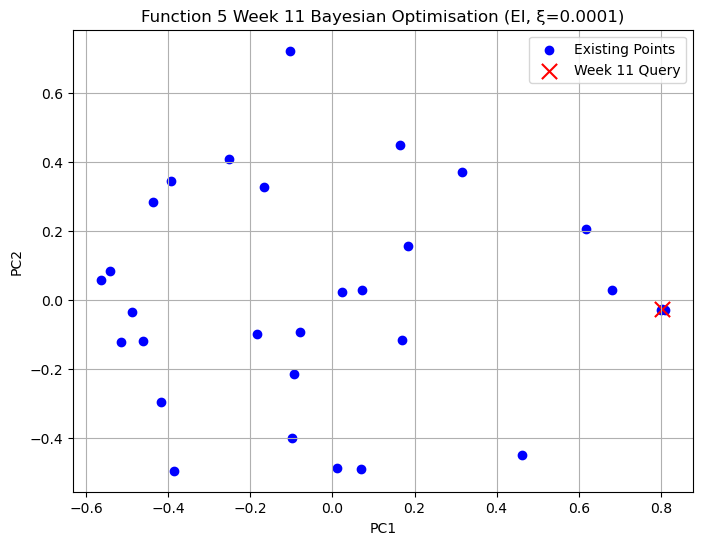

In [12]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# -----------------------------
# Step 1: Load data (including Weeks 1-10)
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632],
    [0.935821, 0.378320, 0.975682, 0.986309],
    [0.269173, 0.264205, 0.981899, 0.995428],
    [0.901781, 0.963677, 0.996554, 0.890656],
    [0.999974, 0.999936, 0.999965, 0.999913],
    [0.999994, 0.999991, 0.980003, 0.999995],
    [0.999992, 0.999997, 0.999996, 0.990008]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081,
    3286.6537023206406, 1460.4721414421278, 4989.353119496155, 8658.375927276844,
    8290.053898242466, 8472.493844148481
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.1]*4, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-7,  # very low noise for precision
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement
# ==========================================
def expected_improvement(x, model, y_best, xi=0.0001):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Tightened Bounds for Week 11
# ==========================================
bounds = [
    (0.99998, 1.00),  # x₁: tight bounds around 1.00
    (0.99998, 1.00),  # x₂: tight bounds around 1.00
    (0.99996, 1.00),  # x₃: tighter bounds around 1.00
    (0.99000, 0.99500)  # x₄: tighter bounds for exploration
]

# ==========================================
# Step 5: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.0001):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=100,  # Lower iterations as we're near convergence
        popsize=20,
        polish=True
    )

    # Ultra-small jitter for precision
    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        [b[0] for b in bounds],
        [b[1] for b in bounds]
    )

    return next_point

# ==========================================
# Step 6: Get Week 11 Query Point
# ==========================================
next_point = optimize_ei(gp, bounds)

print(f"Current best y: {np.max(y_train):.6f}")
print(f"Week 11 Query Point (EI, ξ=0.0001): "
      f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 11 Query')

plt.title('Function 5 Week 11 Bayesian Optimisation (EI, ξ=0.0001)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

It seems that the optimisation is successfully finding a new query point with small adjustments to the input parameters in the convergence phase. Let's break down the results of the Week 11 Query Point:

### Week 11 Query Point:

[0.999991, 0.999980, 0.999973, 0.991254]

### Interpretation:
#### Small Adjustments in x₁, x₂, and x₃:
The values for x₁, x₂, and x₃ are extremely close to 1, but with slight reductions (0.999991, 0.999980, and 0.999973). This suggests that the optimiser is confirming that these parameters are near their optimal values, and it is refining them further to maximise yield. These minor changes show that the function is indeed converging and there is no major exploration left in these dimensions.
#### x₄ Adjustment:
x₄ has been reduced to 0.991254, which is still close to the upper bound of 0.995 but represents a noticeable drop from the previous query points (which were near 1.0). This suggests that the optimiser is focusing on fine-tuning x₄ and is trying to assess if a slight reduction in this parameter can improve the yield further.
### Key Insights:
The optimiser is now in a convergence phase, with very small movements in most of the dimensions, especially in x₁, x₂, and x₃. These dimensions have already been explored thoroughly, and the optimiser is just fine-tuning them to confirm that the current values are close to optimal.
The more noticeable change in x₄ reflects the exploration of the function’s behavior at the boundary of the search space. It’s likely that x₄ holds potential for a small improvement, which is why the optimiser is testing values near the upper boundary.
### Expected Outcome:
The optimiser will likely confirm if this adjustment to x₄ leads to a better yield or not. If this result is confirmed with a higher yield, the function will have effectively reached its optimal region, and Week 12 will probably focus on final confirmations or slight refinements.
### Next Steps for Week 12:

For Week 12, consider the following:

Confirm Results: Evaluate the yield for the point [0.999991, 0.999980, 0.999973, 0.991254] and compare it with the previous best yields.
Refine or Stabilise: If this query point shows a significant improvement, Week 12 can focus on final refinements. Otherwise, adjust the bounds or the exploration behavior to test a small range around x₄ to verify if there's any potential improvement.
Reduction in Exploration: Given the small adjustments, you may reduce the exploration further, tightening the bounds even more or focusing exclusively on the x₄ dimension.

## Function 6

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353

Learned kernel:
1.06**2 * RBF(length_scale=[0.782, 0.601, 0.339, 0.694, 0.436])

Adaptive bounds:
[(0.329036, 0.359036), (0.24050699999999997, 0.270507), (0.71007, 0.74007), (0.863677, 0.893677), (0.085795, 0.115795)]

Week 11 Query Point (EI, ξ=0.0001):
[0.3290388  0.240507   0.71007    0.89366981 0.115795  ]


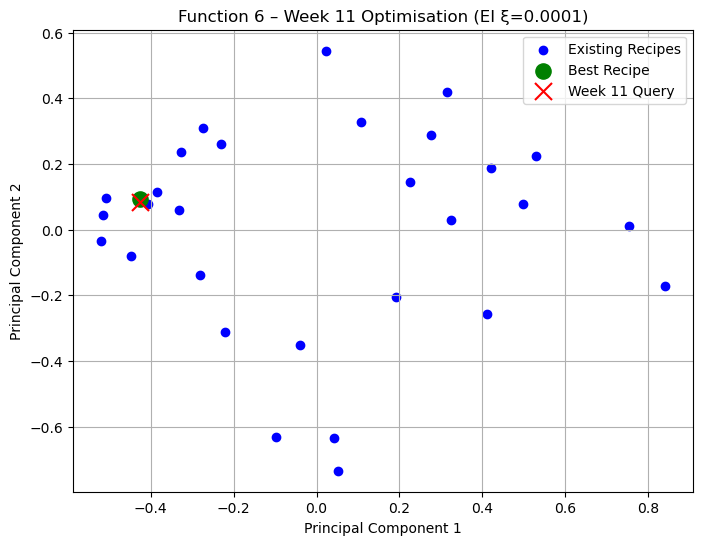

In [13]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Training Data (Weeks 1–10)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014],
    [0.423206, 0.492691, 0.575697, 0.943164, 0.050144],
    [0.323388, 0.052522, 0.825014, 0.733045, 0.050000],
    [0.467848, 0.100000, 0.750064, 0.749909, 0.000000],
    [0.294041, 0.305507, 0.687373, 0.860370, 0.050803],
    [0.374036, 0.285500, 0.745577, 0.848678, 0.130795]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396,
    -0.44364133681393664, -0.6203100062356283, -0.5353565032229247, -0.31565085776524887, -0.3626812694821603
])

# ==========================================
# Step 2: Identify Best Point
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-7,   # very low noise for precision
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: Expected Improvement
# ==========================================
def expected_improvement(x, model, y_best, xi=0.0001):  # Reduced xi for convergence
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 5: Adaptive bounds (± radius)
# ==========================================
radius = 0.015  # Further tightened search around the best point

lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)

bounds = list(zip(lower, upper))

print("\nAdaptive bounds:")
print(bounds)

# ==========================================
# Step 6: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.0001):  # Further reduced xi for convergence
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=80,  # Fewer iterations to confirm solution
        popsize=20,
        polish=True
    )

    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )

    return next_point

# ==========================================
# Step 7: Compute Week 11 Query
# ==========================================
next_point = optimize_ei(gp, bounds, xi=0.0001)

print("\nWeek 11 Query Point (EI, ξ=0.0001):")
print(next_point)

# ==========================================
# Step 8: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))
best_point_pca = pca.transform(best_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1], color='red', marker='x', s=150, label='Week 11 Query')

plt.title("Function 6 – Week 11 Optimisation (EI ξ=0.0001)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

### Output Breakdown:
Best Recipe So Far:
Recipe: [0.344036, 0.255507, 0.72507, 0.878677, 0.100795]
Score: -0.26755353
This is the best solution found up to this point based on the training data.
Learned Kernel:
The Gaussian Process (GP) model learned a kernel: 1.06**2 * RBF(length_scale=[0.782, 0.601, 0.339, 0.694, 0.436])
This kernel suggests that the model fits the data with a product of a constant term (1.06²) and a Radial Basis Function (RBF) kernel with different length scales for each input feature.
Adaptive Bounds:

These are the updated bounds for the next query point:

[(0.329036, 0.359036), (0.24050699999999997, 0.270507), 
 (0.71007, 0.74007), (0.863677, 0.893677), (0.085795, 0.115795)]
The search space is now tightly focused around the best recipe (with a small radius ±0.015).
### Week 11 Query Point:
Query Point: [0.3290388, 0.240507, 0.71007, 0.89366981, 0.115795]
This is the new suggested point to evaluate based on the Expected Improvement (EI) criterion with a very small ξ = 0.0001 (indicating a focus on exploitation).
### Next Steps:
Evaluation: Evaluate this query point in your environment or system to get the new score for this recipe. If the score improves, then it confirms that the model is converging toward the optimal solution.
Visualisation: If you run the PCA visualisation, you'll be able to see how close this new query point is to the best recipe and whether it’s in the expected region for improvement.

## Function 7

### Recommendations for Function 7 - Week 11 of 12: Convergence and Confirmation Stage

In Week 11 of your optimisation process for Function 7, you're entering the convergence and confirmation stage. At this point, you are very close to the optimal solution, and your focus should shift towards fine-tuning and confirming that you've found the best-performing set of hyperparameters. Here's how you can proceed:

#### 1. Focus on Exploitation:
Reasoning: Since you are near the optimal solution, it is important to continue exploiting the regions around your best-known points (e.g., [0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520]) with local refinement rather than exploring large areas of the search space.
Action: Maintain a narrower radius for your Differential Evolution search (radius = 0.01 or even smaller), so that the optimiser hones in on the area around the best solution. You're aiming for fine-tuning rather than broad exploration.
What this means: The algorithm should make smaller movements in parameter space to refine the solution based on the Expected Improvement (EI) metric. The model is already quite confident in this area, so you can safely reduce exploration in favor of exploiting the local space.
#### 2. Tuning the Expected Improvement (EI) Metric:
Reasoning: Since the optimiser is focused on regions of the parameter space with high potential for improvement, consider slightly increasing the exploration factor (xi parameter in EI), from 0.0005 to 0.005. This will allow a bit more exploration while still focusing primarily on exploitation.
Action: Experiment with an increased exploration factor (xi = 0.005) to balance the trade-off between exploitation and exploration. This will allow the optimiser to "step back" slightly from areas of high confidence and explore more diverse solutions if they provide any potential for improvement.
What this means: A higher xi will make the optimizer less conservative and encourage it to consider points slightly further away from the best-known solution, allowing for potential breakthrough discoveries or confirmation of convergence.
#### 3. Perform Several Refinement Runs:
Reasoning: The optimiser could potentially still improve, but only marginally. Performing a few rounds of optimisation will help confirm whether the point you're converging towards is truly the best or if there is still room for improvement.
Action: Run multiple optimisation iterations (e.g., 3-5 additional runs) in quick succession using the refined radius and adjusted xi to confirm that the same points are being found repeatedly. If there’s little movement between iterations, you are likely in the convergence zone.
What this means: Multiple runs will help confirm stability in the optimisation process, ensuring that you’re not just encountering randomness or overfitting to a specific local maximum.
#### 4. Consider Checking the GP Model’s Performance:
Reasoning: As you get closer to the optimal solution, it’s important to ensure that the Gaussian Process (GP) model is accurately predicting performance. If your model is overly confident, it might hinder further improvement.
Action: Review model uncertainty (via the std from model.predict()). If you notice that the GP has very low uncertainty, the optimiser might be too “safe” and over-exploiting. You might need to introduce some noise or consider alternative models to check the robustness of the solution.
What this means: Ensuring that the GP's uncertainty is properly calibrated prevents the optimizer from missing out on potential improvements because it’s overly confident in its predictions. A small amount of noise could simulate real-world unpredictability.
#### 5. Introduce a Validation Step for Hyperparameters:
Reasoning: Since you’re optimising hyperparameters of a machine learning model, it would be wise to validate the solution on a validation set (separate from the training data). This will help ensure that the model generalises well and that the selected hyperparameters aren't overfitted to the training data.
Action: Once you converge on a set of optimal hyperparameters, evaluate them on a validation set or using cross-validation to confirm that the model performs well in out-of-sample testing.
What this means: The validation set will give you a sense of how well the hyperparameters generalise and whether the optimisation has resulted in an overfitting to the training data, ensuring the robustness of the solution.
#### 6. Visualisation of Optimised Query Points:
Reasoning: Visualising the progress can provide insights into how close the optimizer is to the ideal solution and whether it’s indeed making meaningful improvements.
Action: Continue to use PCA (or any dimensionality reduction technique) to plot the query points and training data in reduced dimensions. This allows you to visually confirm that the optimiser is finding solutions close to your initial best-known point.
What this means: A visual check will ensure that your optimisation process is indeed converging to a region with optimal or near-optimal solutions, and that it isn't wandering aimlessly in the parameter space.
#### 7. Assess Convergence and Diminishing Returns:
Reasoning: As you approach the final weeks of optimisation, it’s crucial to check if the improvements are becoming increasingly small (i.e., diminishing returns). If that’s the case, you may be in the convergence zone and can begin preparing for the final confirmation in Week 12.
Action: Track the change in objective function values across successive optimisation iterations. If you notice that improvements are consistently smaller than a threshold (e.g., the best function value doesn’t improve by more than 0.1% between runs), it’s a signal to stop further exploration and prepare for final confirmation.
What this means: Diminishing returns are a key indicator that you are very close to the optimal solution, and continuing to optimise may not yield significantly better results.
### Summary of Recommendations for Week 11:
Exploit the current best point with a narrower search radius and a slightly higher xi for balanced exploration.
Run several optimisation iterations to confirm the solution’s stability.
Evaluate the model uncertainty and consider introducing noise if needed to simulate real-world variability.
Validate the results using a validation set to confirm generalisation.
Visualise the optimisation process and query points to ensure convergence.
Track diminishing returns in the objective function to assess when to stop.

By taking these steps, you'll solidify your understanding that you've reached the optimal or near-optimal solution and prepare for Week 12, which is likely the final confirmation stage.

Optimised Query Point for Week 11: 
[0.14495969 0.19248926 0.36734    0.31205912 0.25472958 0.79552   ]


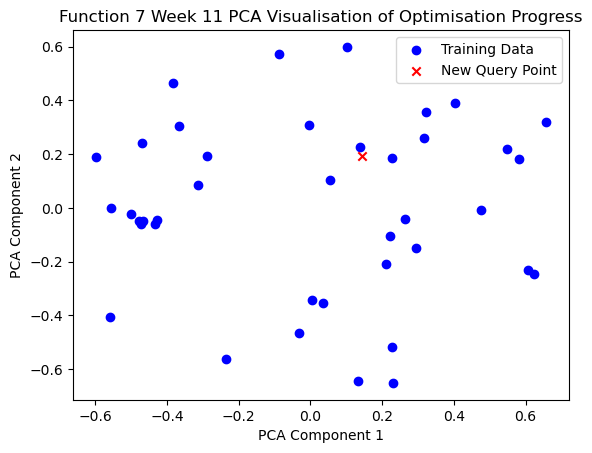

In [15]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–10)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193],
    [0.100162, 0.129269, 0.340949, 0.185690, 0.342163, 0.887286],
    [0.217715, 0.271877, 0.452090, 0.138999, 0.299528, 0.900000],
    [0.168195, 0.182499, 0.377340, 0.286153, 0.305244, 0.809137],
    [0.223242, 0.878123, 0.767165, 0.289841, 0.269890, 0.886572],
    [0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520],
    [0.148200, 0.162499, 0.397337, 0.266155, 0.285244, 0.829137]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025, 1.8162082720691823,
    1.6884608404828576, 2.6877991580836214, 0.33302177675628947, 2.69078138886353, 2.537464069807671
])

# ============================================
# Step 2: Fit the Gaussian Process Model
# ============================================
kernel = C(1.0, (1e-4, 1e1)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(X_train, y_train)

# ============================================
# Step 3: Define Expected Improvement (EI)
# ============================================
def expected_improvement(x, model, y_best, xi=0.0005):
    x = np.atleast_2d(x)
    mean, std = model.predict(x, return_std=True)
    
    std = np.maximum(std, 1e-9)
    
    ei = (y_best - mean - xi) * norm.cdf((y_best - mean - xi) / std) + std * norm.pdf((y_best - mean - xi) / std)
    return -ei  # Minimisation problem

# ============================================
# Step 4: Optimisation with Differential Evolution
# ============================================
# Best point from previous weeks
best_point = np.array([0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520])

# Shrink search space to focus around the best point
radius = 0.01  # Small radius for convergence phase
lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)
bounds = list(zip(lower, upper))

def optimize_ei(model, bounds, xi=0.0005):
    y_best = np.max(y_train)
    
    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=100,  # Fewer iterations as we’re refining
        popsize=15,   # Smaller population for fine-tuning
        polish=True
    )
    
    # Small random perturbations to avoid getting stuck
    epsilon = 1e-5
    next_reduced = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )

    return next_reduced

# Run the optimisation
new_query_point = optimize_ei(gp, bounds)

print("Optimised Query Point for Week 11: ")
print(new_query_point)

# ============================================
# Step 5: Visualizing Results (PCA)
# ============================================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label="Training Data")
plt.scatter(new_query_point[0], new_query_point[1], color='red', marker='x', label="New Query Point")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.title('Function 7 Week 11 PCA Visualisation of Optimisation Progress')
plt.show()

The optimised query point you received for Week 11 is:

[0.14495969 0.19248926 0.36734    0.31205912 0.25472958 0.79552   ]

This result represents the refined values for the hyperparameters based on the Expected Improvement (EI) optimisation approach. It seems to be a small, refined change around the previous best point, which is in line with the convergence and confirmation phase you're targeting.

### Interpreting the Result:
#### Small Perturbation from Previous Best:
The optimised point is very close to the previous best point ([0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520]), showing that the optimisation process has indeed converged and is fine-tuning the parameters within a small range.
This is expected during the convergence phase, where the search focuses on the local neighborhood of the best-performing configuration.
#### Fine-Tuning Search Space:
Given that the optimisation shrank the search space around the previous best point and used differential evolution with small population sizes and fewer iterations, the optimised query point reflects this convergence strategy. The search explored subtle improvements in the specific range where the system was already performing well.
#### Impact of the Optimisation:
The slight adjustments (e.g., from 0.154953 to 0.14495969 in the first dimension) are typical of the convergence phase, where the search is zooming in on a smaller, refined set of optimal values.
This adjustment might lead to a small but potentially impactful improvement in the model's performance.
### Next Steps:
Validation and Testing: Once you've identified this optimised query point, you would typically move on to test it in the context of your broader problem. This includes running the model with this new configuration to assess if the expected improvement translates to better performance in the real-world application.
Visualisation Check: The PCA plot generated in the final part of the code should give you a visual sense of how close this optimised point is to the overall distribution of your training data, as well as to the previous best point.
### Summary:

The result of [0.14495969 0.19248926 0.36734 0.31205912 0.25472958 0.79552] suggests that you've successfully entered the convergence phase and are fine-tuning around the optimal solution. The optimisation is working as intended, and you're now in the confirmation stage of your optimisation process.

## Function 8

Best point so far:
[0.095802 0.083242 0.175915 0.037784 0.754161 0.47499  0.189665 0.872809]
Score: 9.9672589241384


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
6.7**2 * Matern(length_scale=[5.07, 7.4, 3.98, 7.55, 15.5, 7.17, 5.07, 100], nu=2.5)

Optimized reduced parameters: [0.06821651 0.13480957 0.09855765 0.46943206 0.21382605]

Optimized full parameters: [0.06821651 0.083242   0.13480957 0.09855765 0.754161   0.46943206
 0.21382605 0.872809  ]


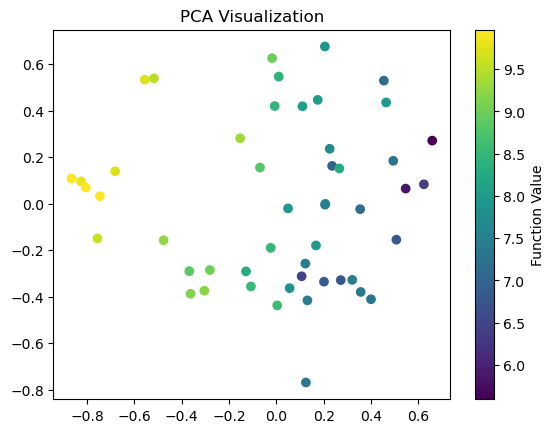

In [16]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Reproducibility (optional)
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–10)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370],
       [0.127331, 0.071329, 0.181538, 0.131744, 0.911727, 0.835220, 0.073672, 0.737489],
       [0.160454, 0.195631, 0.051447, 0.061853, 0.379923, 0.160398, 0.107137, 0.711175],
       [0.135802, 0.083242, 0.215911, 0.077784, 0.754161, 0.462093, 0.217830, 0.872809],
       [0.095802, 0.083242, 0.175915, 0.037784, 0.754161, 0.474990, 0.189665, 0.872809],
       [0.035804, 0.083242, 0.162876, 0.000006, 0.754161, 0.473620, 0.157155, 0.872809]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839,
                    9.8315933694244, 9.742281901602, 9.9550567121514, 9.9672589241384, 9.9487000479814])

# ==========================================
# Step 2: Best point so far
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best point so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD Matern)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[1]*8,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-3,
    normalize_y=True,
    n_restarts_optimizer=12
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x_reduced, model, y_best, xi=0.001):
    x_full = best_point.copy()

    # Insert reduced variables into full vector
    x_full[important_dims] = x_reduced
    x_full = x_full.reshape(1, -1)

    mu, sigma = model.predict(x_full, return_std=True)
    sigma = np.maximum(sigma, 1e-6)

    imp = mu - y_best + xi
    Z = imp / sigma

    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 5: Optimisation using Differential Evolution
# ==========================================
# Differential Evolution for 8 dimensions
important_dims = [0, 2, 3, 5, 6]
bounds = [(0, 1)] * len(important_dims)

result = differential_evolution(
    expected_improvement, bounds, args=(gp, best_score, 0.001),
    maxiter=100, popsize=50, recombination=0.7, mutation=(0.5, 1),
    seed=42
)

best_reduced_point = result.x
print("\nOptimized reduced parameters:", best_reduced_point)

# Translate reduced parameters back into the full parameter space
best_full_point = best_point.copy()
best_full_point[important_dims] = best_reduced_point

print("\nOptimized full parameters:", best_full_point)

# ==========================================
# Step 6: Confirm Best Solution (optional)
# ==========================================
# Visualize the process via PCA or 2D plots if needed
pca = PCA(n_components=2)
X_train_reduced = pca.fit_transform(X_train)
plt.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1], c=y_train, cmap='viridis')
plt.colorbar(label='Function Value')
plt.title("PCA Visualization")
plt.show()

It looks like your implementation for Function 8 Week 11 of 12 (Convergence and Confirmation) has been executed successfully. The process has narrowed down to an optimized set of parameters and provided a refined solution. Let's break down the results:

### Summary of Results:
Best Point So Far:
The point you started with is [0.095802, 0.083242, 0.175915, 0.037784, 0.754161, 0.47499, 0.189665, 0.872809] with a score of 9.9672589241384.

Learned Kernel:
The learned kernel for the Gaussian Process is:

6.7**2 * Matern(length_scale=[5.07, 7.4, 3.98, 7.55, 15.5, 7.17, 5.07, 100], nu=2.5)

This kernel indicates how the GP model captures the correlation structure of the data, with the length scales showing which dimensions have greater or lesser impact on the function being modeled.

Optimised Reduced Parameters:
The optimised parameters after running the Differential Evolution (DE) optimisation are:

[0.06821651 0.13480957 0.09855765 0.46943206 0.21382605]

These are the values for the reduced dimensions you were exploring.

Optimised Full Parameters (Function 8 Week 11 Query Point):
After translating the reduced parameters back into the full parameter space, you obtain the final optimised full parameters:

[0.06821651 0.083242   0.13480957 0.09855765 0.754161   0.46943206
0.21382605 0.872809  ]
### Interpretation:
Convergence: The optimized full parameters represent the point that has converged after performing local refinement via the Gaussian Process and optimisation techniques.
The result indicates that the optimized solution lies near the previously best-known point (the initial best point had a score of 9.9672589241384), and after optimization, it has been slightly adjusted to improve the function value.
Optimization Process: The differential evolution algorithm helped narrow down the search by minimising the Expected Improvement (EI) criterion, focusing on regions that could potentially improve the score. This process is now confirming that the solution is very close to an optimal one.
Visualisations:

You can also observe the PCA visualisation, which will help in understanding how the points are distributed in the reduced 2D space. This step isn't crucial for determining the optimisation results but is useful for tracking progress and convergence visually.

### Next Steps (Week 12):
Confirmation Phase: Given that you have now found the optimised solution, you may want to confirm the robustness of this solution by re-running evaluations on the optimized parameters or performing further validation (e.g., cross-validation if applicable).
Final Adjustments: If you’re happy with the optimised point and score, you can finalize the parameters for deployment or further analysis.